# ResoKit's Tutorial

This tutorial is a guide to use ResoKit package.
ResoKit is toolkit package for the analysis and diagnostics of resonances in exoplanetary planetary systems.

In this tutorial we show, step by step, how to get started with the ResoKit package.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit

## Loading the data

The first step is to load an exoplanetary system. The available datasets are [NASA](https://exoplanetarchive.ipac.caltech.edu/) or [EU](https://exoplanet.eu/home/).
Both datasets are provided with the package, and they can be updated if necessary.

To load a system, functions `load_system_from_nasa` and `load_system_from_eu` are provided in the `io` module.

For this tutorial, we will work with the  `Kepler-47` exoplanetary system, from the Exoplanet.eu dataset.

Remember to download the datasets first. See the [datasets tutorial](./datasets.ipynb) for more information.

In [2]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47", soft=True)

Looking for star system 'Kepler-47' in eu database.
 Loading the entire dataset...
  Reading exoplanet_eu.csv directly from /home/egianuzzi/.resokit_data/exoplanet_eu.zip...
Updated stored index in memory.
Stored dataset in memory.
 Found a very close star match: 'Kepler-47 A' in eu dataset.
 Execute with exact_match=False to load it, or rewrite the name.


Note: If we set _soft=False_ (default), a `ValueError` is raised if the system is not found. 

If the system (or star in this case) name is entered incorrectly, ResoKit will attempt to detect the intended system and provide suggestions based on it.
As Exoplanet.eu is indexed through star name, we see here that the correct system (star) name is `Kepler-47 A`.

In [3]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47 A")

Looking for star system 'Kepler-47 A' in eu database.
 Loaded full dataset from memory stored datasets.
Checking if 'Kepler-47 A' is a binary system...
 Found a very close binary match in: ['Kepler47']
 Execute with exact_match=False to load it.
Star Kepler-47 A could be part of a binary system.
Creating system 'Kepler-47'.
 Star 'Kepler-47 A' created.
 3 planets created.


It seems that Kepler-47 is a binary star system, so we wil try then to load the system using `exact_match=False`.

The main problem is that both databases have different star and system names, but using `exact_match=False` an approximate link between them will be done.

In this case we can remove the " A", and keep the hyphen "-".

In [4]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47", exact_match=False)

Looking for star system 'Kepler-47' in eu database.
 Loaded full dataset from memory stored datasets.
 Found a very close star match: 'Kepler-47 A' in eu dataset.
 Loading the almost exact match...
Checking if 'Kepler-47 A' is a binary system...
 Binary system found in ['Kepler47'], in p-type binary orbit.
Creating system 'Kepler-47'.
 Using binary star 'Kepler-47'.
 3 planets created.


Now, `kepler47` is a Static System; and we also know that it is a circumbinary planets system.

We can see its components (star and planets) and where the system was obtained from.

In [5]:
kepler47

StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

Note: 

Just in case we do not want the system to be a binary star system (even though it is), we can execute the previous with `check_binary=False`.

In [6]:
resokit.io.load_system_from_eu("Kepler-47", exact_match=False, check_binary=False)

Looking for star system 'Kepler-47' in eu database.
 Loaded full dataset from memory stored datasets.
 Found a very close star match: 'Kepler-47 A' in eu dataset.
 Loading the almost exact match...
Creating system 'Kepler-47'.
 Star 'Kepler-47 A' created.
 3 planets created.


StaticSystem: 'Kepler-47 A'
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
from 'eu' data source.

## Analysing the Static System

Some features we can apply to this System are:

- System planets parameters: `get_item`
- Individual planet inspection: `planet`
- Calculate period ratios: `period_ratios`
- Plot planet, star, of general system attributes: `plot`
- Remove or add a planet: `remove`, `add`
We will now explain how to use each of them.

### Inspection

We can access the parameters of every planet as if it were a dataframe, though the slice method

For example the **mass**

In [7]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

Or the **radius** and the **P**eriod

In [8]:
kepler47[["radius", "P"]]

,radius,P
Kepler-47 (AB)b,0.2700,49.514
Kepler-47 (AB)d,0.6281,187.350
Kepler-47 (AB)c,0.4100,303.148


Another method is using the `get_item` method.

For example, for the **e**ccentricity and **inc**lination; and its errors too!

In [9]:
kepler47.get_item(["e", "inc"], error=True)

,e,e_err_min,e_err_max,inc,inc_err_min,inc_err_max
Kepler-47 (AB)b,NaN,NaN,NaN,89.590,0.5,0.5
Kepler-47 (AB)d,0.024,0.017,0.025,90.000,NaN,NaN
Kepler-47 (AB)c,NaN,NaN,NaN,89.826,NaN,NaN


### Planet access

We can access any planet (or even the system star) from the Static System.

For example, if we want to retrieve the 2nd planet (**sorted by period**), we simply do

In [10]:
planet2 = kepler47.planet(1) # Remember python is 0 indexed, so the second planet is "1".
planet2

,4723
disc_method,Timing
P_err_min,0.15
tperi_err_max,NaN
inc,90.0
radius_err_min,0.0437
a,0.6992
reference,Published in a refereed paper
n_err_min,41.887902
radius,0.6281
w_err_max,96.0


We can display the planet properties as a Series.

In [11]:
planet2.data

disc_method                                  Timing
P_err_min                                      0.15
tperi_err_max                                   NaN
inc                                            90.0
radius_err_min                               0.0437
a                                            0.6992
reference             Published in a refereed paper
n_err_min                                 41.887902
radius                                       0.6281
w_err_max                                      96.0
P_err_max                                      0.15
mass_err_min                                 0.0368
w                                             352.0
a_err_max                                    0.0033
e                                             0.024
e_err_max                                     0.025
n                                          0.033537
w_err_min                                     166.0
P                                            187.35
inc_err_min 

And we can access any of this attributes.
For example the _name_, or the semi-major axis _a_:

In [12]:
planet2.name

'Kepler-47 (AB)d'

In [13]:
planet2.a

0.6992

Just, remember the main units!
Semimajor-axis ($a$) is in Astronomical Units.

### Calculate and plot (if possible) period ratios

If we want to obtain the period ratio between all pair of planets: $P_{i+1}/P_{i}$, we simply invoke Static System `period_ratios_` attribute.

In [14]:
kepler47.period_ratios_

,Kepler-47 B,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 B,1.000000,5.729139,21.677794,35.076487
Kepler-47 (AB)b,0.174546,1.000000,3.783778,6.122470
Kepler-47 (AB)d,0.046130,0.264286,1.000000,1.618084
Kepler-47 (AB)c,0.028509,0.163333,0.618015,1.000000


Here we can see that $P_\textnormal{Kepler-47 (AB)c} \sim 6.122470 \times P_\textnormal{Kepler-47 (AB)b}$ .

If we want to get the period ratios as fractions, we simply invoke Static System `pair_ratio` method, including (if wanted) any `resokit.utils.float_to_fraction` function argument. For example: _max_error_ (which is the maximum relative error between the estimated fraction and the floating period ratio).

In [15]:
kepler47.pair_ratio("all", max_error=1e-1, use_binary=False)

Approximating float 1.000000 as a continued fraction:
 Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.264286 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/3   -> 0.333333 (error: 2.61e-01)
 Iter  3:   1/4   -> 0.250000 (error: 5.41e-02)
Approximating float 0.163333 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/6   -> 0.166667 (error: 2.04e-02)
Approximating float 3.783778 as a continued fraction:
 Iter  1:   3/1   -> 3.000000 (error: 2.07e-01)
 Iter  2:   4/1   -> 4.000000 (error: 5.71e-02)
Approximating float 1.000000 as a continued fraction:
 Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.618015 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/1   -> 1.000000 (error: 6.18e-01)
 Iter  3:   1/2   -> 0.500000 (error: 1.91e-01)
 Iter  4:   2/3   -> 0.666667 (error: 7.87e-02)
Approximating float 6.122470 as a continued fraction

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,"(1, 1)","(4, 1)","(6, 1)"
Kepler-47 (AB)d,"(1, 4)","(1, 1)","(3, 2)"
Kepler-47 (AB)c,"(1, 6)","(2, 3)","(1, 1)"


Here, is more clear that $P_\textnormal{Kepler-47 (AB)b}$ and $P_\textnormal{Kepler-47 (AB)c}$ are somewhat _close_ to a $6/1$ mean motion resonance.
Moreover, we also see that $P_\textnormal{Kepler-47 (AB)d}$ and $P_\textnormal{Kepler-47 (AB)c}$ are somewhat _close_ to a $3/2$ mean motion resonance.

In case the errors (of the period ratio estimations) are needed, they can be obtained invoking Static System  `pair_ratio` method again, with `errors=True`.
They are calculated using each observed period error, so each value is an upper limit for the error.

Here we also calculate the error for the period ratios including the binary star. 

In [16]:
kepler47.pair_ratio(error=True)

,Kepler-47 B,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 B,NaN,NaN,NaN,NaN
Kepler-47 (AB)b,NaN,0.001142,0.004304,0.005155
Kepler-47 (AB)d,NaN,0.000301,0.001132,0.001351
Kepler-47 (AB)c,NaN,0.000138,0.000516,0.000336


As expected, the errors related to the binary star are `NaN` because the binary period has no errors set.

#### Plot the period ratios

If the system has a _triplet_ (three planets or more), it can be plotted in a period ratios separations space: $P_{i+1}/P_{i}$ vs. $P_{i+2}/P_{i+1}$.
To do so, we invoke Static System `plot_triplet` method. Here, we also plot the errors.

Text(0, 0.5, 'Period Ratio ($P_3/P_2$)')

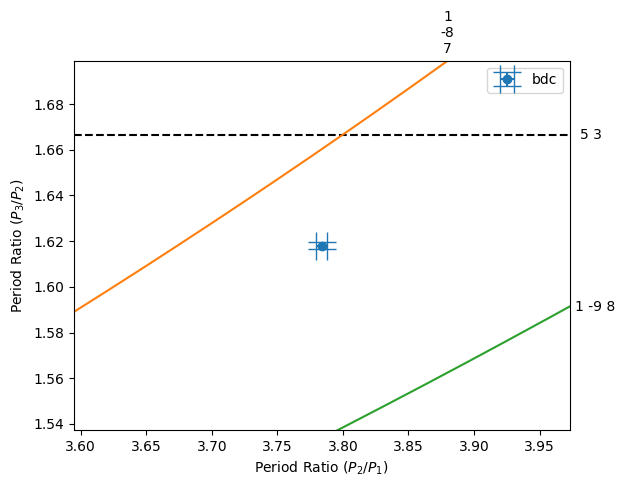

In [17]:
ax = kepler47.plot_triplet(error=True, capsize=10)
ax.legend()
ax.set_xlabel("Period Ratio ($P_2/P_1$)")
ax.set_ylabel("Period Ratio ($P_3/P_2$)")

Note: The binary is **not** included in these triplet plots (_yet_).

If we want more manual operation at plotting 3-body mean motion resonances near the system triplets, we can invoke the `resokit.utils.mmr.plot_mmrs` method. Also, we set `draw_mmr=False` to avoid plotting them twice.

This method will plot the resonances that are near the triplets.

Note: It its highly recommended to set the axes limits (xlim and ylim) **before** calling `plot_mmrs`, especially if *label_mmrs=True*.

Text(0, 0.5, 'Period Ratio ($P_3/P_2$)')

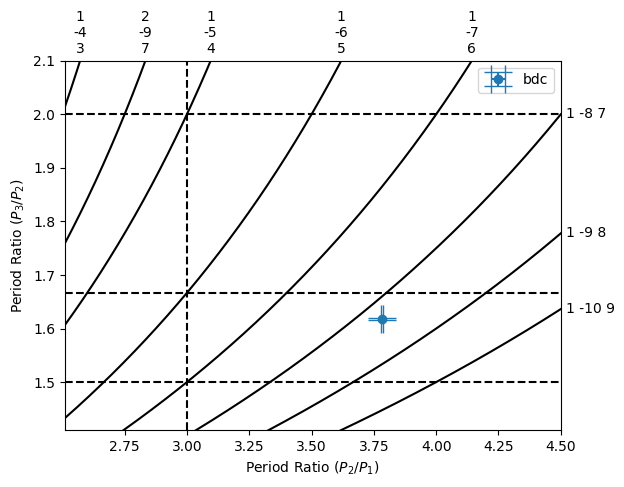

In [18]:
bounds = [2.51, 4.5, 1.41, 2.1]  # [xmin, xmax, ymin, ymax]
ax = kepler47.plot_triplet(error=True, capsize=10, label=True, draw_mmr=False)
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])
resokit.utils.mmr.plot_mmrs(
    bounds=bounds,
    ax=ax,
    label_mmrs=True,
    color="black",
    )
ax.legend()
ax.set_xlabel("Period Ratio ($P_2/P_1$)")
ax.set_ylabel("Period Ratio ($P_3/P_2$)")

Here, the 3-body resonances are annotated with the corresponding period ratios.

### Plot system attributes

We can plot any pair attributes of the StaticSystem, of any planet in the system.

Text(0, 0.5, 'Radius ($R_J$)')

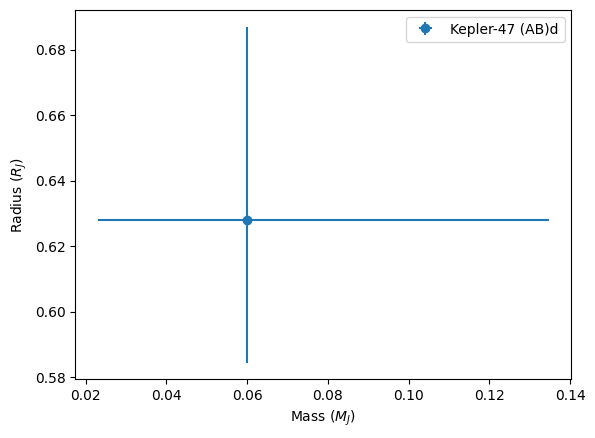

In [19]:
ax = kepler47.plot("mass", "radius", error_x=True, error_y=True)
ax.legend()
ax.set_xlabel("Mass ($M_J$)")
ax.set_ylabel("Radius ($R_J$)")

Some planets are not plotted because they do not have both requested attributes measured.

For example, in this case...

In [20]:
kepler47["radius"]

Kepler-47 (AB)b    0.2700
Kepler-47 (AB)d    0.6281
Kepler-47 (AB)c    0.4100
Name: radius, dtype: float64

We see the three planets have radius estimations; but...

In [21]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

only `Kepler-47 (AB)d` has its mass estimated.

### Estimations

To solve this problem, `ResoKit` also provides tools for mass (or radius) estimation with diverse models, from the estimated radius (or mass).

To do so, we simply use `estimate_mass` function.

In [22]:
kepler47.estimate_mass()

Kepler-47 (AB)b    0.028560
Kepler-47 (AB)d    0.059840
Kepler-47 (AB)c    0.058047
Name: mass, dtype: float64

Here we used the default `estimate_mass` parameters, but we can get different estimations with different models, and also include the errors.

In [23]:
kepler47.estimate_mass(model="m24", err_method=2)

,mass,mass_err_min,mass_err_max
Kepler-47 (AB)b,0.037818,0.002276,0.002322
Kepler-47 (AB)d,0.059840,0.036800,0.074900
Kepler-47 (AB)c,0.070546,0.004572,0.004672


The models available for mass-radius relations are:

- 'ck17': [Chen & Kipping (2017)](https://iopscience.iop.org/article/10.3847/1538-4357/834/1/17) [trivariate] (Naive approximation)
- 'o20': [Otegi et al. (2020)](https://www.aanda.org/articles/aa/abs/2020/02/aa36482-19/aa36482-19.html) [density|bivariate]
- 'e23': [Edmondson et al. (2023)](https://doi.org/10.48550/arXiv.2310.16733) 
- 'm24': [Müller et al. (2024)](https://www.aanda.org/articles/aa/full_html/2024/06/aa48690-23/aa48690-23.html) [bivariate]

## Remove or add planets

### Remove

To remove a planet, we can simply invoke the `remove_planet` method of StaticSystem.

In [24]:
modified_kepler47 = kepler47.remove_planet(2)  # Remember python is 0 indexed, so the third planet is "2".
modified_kepler47

Planet Kepler-47 (AB)c [2] removed.


StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
 [circumbinary system]
from 'eu' data source.

We can also remove planets by suffix.

In [25]:
modified_kepler47.suffixes_

['A', 'B', 'b', 'd']

In [26]:
modified_kepler47 = kepler47.remove_planet("b")
modified_kepler47

Planet Kepler-47 (AB)b [0] removed.


StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

In [27]:
# We check that the number of planets has been reduced
modified_kepler47.n_planets_

2

We can look the new system metadata, and we will find that 'removed_planet' has been added. Also some extra information can be found...

In [28]:
for k,v in modified_kepler47.metadata.items():
    print(k, v)

ResoKit 0.1.dev256
author Emmanuel Gianuzzi
author_email egianuzzi@unc.edu.ar
affiliation FAMAF-IATE-OAC-CONICET
platform Linux-6.8.0-60-generic-x86_64-with-glibc2.35
system_encoding utf-8
python 3.10.12 (main, May 27 2025, 17:12:29) [GCC 11.4.0]
license MIT
load_system Kepler-47
eu_indexes [4721, 4722, 4723]
removed_planet ['Kepler-47 (AB)b']


### Add

To add a planet, we can simply invoke the `add_planet` method of StaticSystem.

In [29]:
# Get a planet from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

In [30]:
# Add the planet to the modified system
modified_kepler47.add_planet(planet2)

Planet Kepler-47 (AB)d added.


<attrs generated init resokit.core.StaticSystem>:31: UserWarning: Planets must have unique names.
  self.__attrs_post_init__()


StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

Here, we added a planet that already exists in the system, so a Warning was raised.

If a planet not existing in the system is added, no warning will be raised.

In [31]:
# Extract the planet 2 from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

# Remove the planet from the original system
modified_kepler47 = kepler47.remove_planet(1)

# Add again the planet to the modified system
modified_kepler47 = modified_kepler47.add_planet(planet2)

# Check that the planet has been added
modified_kepler47

Planet Kepler-47 (AB)d [1] removed.
Planet Kepler-47 (AB)d added.


StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

### Replace

Another feature possible to do with this `StaticSystem` is to replace a planet with another.

Lets take for example _Kepler-47 (AB)b_.

In [32]:
kepler47_b = kepler47.planet("b")
kepler47_b

,4721
disc_method,Primary Transit
P_err_min,0.04
tperi_err_max,NaN
inc,89.59
radius_err_min,0.011
a,0.2956
reference,Published in a refereed paper
n_err_min,157.079633
radius,0.27
w_err_max,NaN


We see again that this planet doesn't have its mass measured...

but we can estimate it and *create a **new** planet* with the estimated mass.

In [33]:
new_kepler47_b = kepler47_b.estimate_mass(new_planet=True)
new_kepler47_b.mass

np.float64(0.02856032033128007)

We can see the modified metadata of this new planet.

In [34]:
for k,v in new_kepler47_b.metadata.items():
    print(k, v)

ResoKit 0.1.dev256
author Emmanuel Gianuzzi
author_email egianuzzi@unc.edu.ar
affiliation FAMAF-IATE-OAC-CONICET
platform Linux-6.8.0-60-generic-x86_64-with-glibc2.35
system_encoding utf-8
python 3.10.12 (main, May 27 2025, 17:12:29) [GCC 11.4.0]
license MIT
load_system Kepler-47
eu_indexes 4721
history ['Added mass to 0.02856032033128007.']


Now, we can replace the old _b_ planet with the new one using `replace`.

In [35]:
new_kepler47 = kepler47.replace_planet("b", new_kepler47_b)
new_kepler47

Planet Kepler-47 (AB)b [0] replaced by Kepler-47 (AB)b.


StaticSystem: 'Kepler-47'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler-47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]

We can verify the mass of the new planet.

In [36]:
new_kepler47.get_item("mass")

Kepler-47 (AB)b    0.02856
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

Finally, as expected, the metadata and source of the new system has also changed from the original.

In [37]:
print("Old source:", kepler47.source_)
print("New source:", new_kepler47.source_)

print("Metadata:")
for k,v in new_kepler47.metadata.items():
    print(k, v)

Old source: eu
New source: user
Metadata:
ResoKit 0.1.dev256
author Emmanuel Gianuzzi
author_email egianuzzi@unc.edu.ar
affiliation FAMAF-IATE-OAC-CONICET
platform Linux-6.8.0-60-generic-x86_64-with-glibc2.35
system_encoding utf-8
python 3.10.12 (main, May 27 2025, 17:12:29) [GCC 11.4.0]
license MIT
load_system Kepler-47
eu_indexes [4721, 4722, 4723]
changed_planet ['Kepler-47 (AB)b']
